**Goal:** run the **whole** EDA loop -- clean, explore each variable, read relationships, synthesize
findings -- on a dataset you have not seen before. This is Unit III's capstone: the L07 mindset, the L08
numbers and one-variable plots, and the L09 visual reading, applied end-to-end and ending in sentences.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u03_eda/l10_lab_eda_mini_project.ipynb)

> This page is the read-only view. To run the lab, open the notebook (`l10_lab_eda_mini_project.ipynb`)
> -- in Colab via the badge above, or locally. Every text output below comes from actually running the
> cells; the plots render live in the notebook.

> **Where this sits:** the capstone of **Unit III** -- builds on L07 (mindset), L08 (one-variable stats
> and plots), and L09 (visual methods). The single *number* for how two variables move together --
> correlation -- is **L19**; here we read relationships by eye and by group.

## The Problem

What drives house prices? Real estate is the largest financial asset most families own. In Puerto Rico,
the post-Maria market rebounded unevenly by municipality, and headline averages hid wildly different
local stories. A full EDA is exactly the tool that separates them. Today's dataset: **Ames Housing** --
1,460 home sales in Ames, Iowa (2006-2010; De Cock 2011, *Journal of Statistics Education*; via the
OpenML/Kaggle "House Prices" data, CC BY-NC-SA 4.0, educational use). We use a 12-column subset: a mix of
numeric and categorical variables, real missing values, and a clear target, `SalePrice`.

## Prerequisites & Setup

Run the setup cells first. The data is bundled as `data/ames_subset.csv` (the cell falls back to a
one-time OpenML download if the file is absent). No random numbers -- everyone sees identical results.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + load the data (bundled, with an OpenML fallback)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CACHE = "data/ames_subset.csv"
COLS = ["SalePrice", "GrLivArea", "LotArea", "YearBuilt", "OverallQual",
        "BedroomAbvGr", "FullBath", "GarageArea", "Neighborhood",
        "HouseStyle", "LotFrontage", "MasVnrArea"]

if os.path.exists(CACHE):
    df = pd.read_csv(CACHE)
else:
    from sklearn.datasets import fetch_openml
    raw = fetch_openml("house_prices", version=1, as_frame=True, parser="auto")
    df = raw.frame[COLS].copy()
    os.makedirs("data", exist_ok=True)
    df.to_csv(CACHE, index=False)

print(df.shape)
df.head(3)

(1460, 12)


,SalePrice,GrLivArea,LotArea,YearBuilt,OverallQual,BedroomAbvGr,FullBath,GarageArea,Neighborhood,HouseStyle,LotFrontage,MasVnrArea
0,208500,1710,8450,2003,7,3,2,548,CollgCr,2Story,65.0,196.0
1,181500,1262,9600,1976,6,3,2,460,Veenker,1Story,80.0,0.0
2,223500,1786,11250,2001,7,3,2,608,CollgCr,2Story,68.0,162.0


<details><summary>Expected Output</summary>

~~~text
(1460, 12)
~~~
*(...followed by the first three rows: house IDs 1-3, two 2Story homes in CollgCr and a 1Story in
Veenker, with their features. The SalePrices are 208500, 181500, 223500.)*
</details>

## Step 1: First Look -- Structure, Quality, Headline Numbers

The L07 ritual on a dataset you have not seen: *what is here*, *what is broken*, *what are the headline
numbers*.

### 1a. Structure and types

In [3]:
print(df.dtypes)

SalePrice         int64
GrLivArea         int64
LotArea           int64
YearBuilt         int64
OverallQual       int64
BedroomAbvGr      int64
FullBath          int64
GarageArea        int64
Neighborhood     object
HouseStyle       object
LotFrontage     float64
MasVnrArea      float64
dtype: object


<details><summary>Expected Output</summary>

~~~text
SalePrice         int64
GrLivArea         int64
LotArea           int64
YearBuilt         int64
OverallQual       int64
BedroomAbvGr      int64
FullBath          int64
GarageArea        int64
Neighborhood     object
HouseStyle       object
LotFrontage     float64
MasVnrArea      float64
dtype: object
~~~
</details>

Before plotting anything, classify each column by the L07 variable types:

| Type | Meaning | Columns here |
|------|---------|--------------|
| Numeric -- continuous | any real value in a range | SalePrice, GrLivArea, LotArea, GarageArea, LotFrontage, MasVnrArea |
| Numeric -- discrete | whole-number counts/years | YearBuilt, BedroomAbvGr, FullBath |
| Categorical -- ordinal | ordered categories | OverallQual (1=poor to 10=excellent) |
| Categorical -- nominal | unordered categories | Neighborhood, HouseStyle |

`OverallQual` looks numeric but is **ordinal** -- the gap between quality 3 and 4 is not the same as 9 to
10 (the L07 lesson). **Uncomment and complete** the four classifications:

In [4]:
# Classify each column. Choose from: Continuous / Discrete / Nominal / Ordinal
# MasVnrArea   (masonry veneer area, sq ft)  -> ____
# Neighborhood (neighbourhood name)          -> ____
# OverallQual  (quality rating 1-10)         -> ____
# YearBuilt    (year of construction)        -> ____

<details><summary>Expected Answers</summary>

~~~text
MasVnrArea   -> Continuous  (non-negative real; fractions of a sq ft possible)
Neighborhood -> Nominal     (named places; no ordering)
OverallQual  -> Ordinal     (1-10 ordered; gaps unequal)
YearBuilt    -> Discrete    (integer years; ordered; not a count)
~~~
</details>

### 1b. Missing values and duplicates

In [5]:
print(df.isnull().sum().sort_values(ascending=False))
print("Duplicate rows:", df.duplicated().sum())

LotFrontage     259
MasVnrArea        8
SalePrice         0
GrLivArea         0
LotArea           0
YearBuilt         0
OverallQual       0
BedroomAbvGr      0
FullBath          0
GarageArea        0
Neighborhood      0
HouseStyle        0
dtype: int64
Duplicate rows: 0


<details><summary>Expected Output</summary>

~~~text
LotFrontage     259
MasVnrArea        8
SalePrice         0
GrLivArea         0
LotArea           0
YearBuilt         0
OverallQual       0
BedroomAbvGr      0
FullBath          0
GarageArea        0
Neighborhood      0
HouseStyle        0
dtype: int64
Duplicate rows: 0
~~~
</details>

**Read it:** `LotFrontage` (street frontage in feet) is missing for 259 of 1,460 houses (~18%);
`MasVnrArea` (masonry veneer) for 8; no duplicate rows. Count the damage *first* -- pandas silently skips
NaNs in every statistic below (the L07 sentinel lesson).

### 1c. Headline numbers

In [6]:
print(df["SalePrice"].describe())
print(f"\nmean / median ratio: {df['SalePrice'].mean() / df['SalePrice'].median():.2f}")

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

mean / median ratio: 1.11


<details><summary>Expected Output</summary>

~~~text
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

mean / median ratio: 1.11
~~~
</details>

**Read it:** the mean ($180,921) sits above the median ($163,000) -- right skew (the L08 signature: a tail
of expensive homes pulls the average up). The middle 50% of sales fall between $130k and $214k.

## Step 2: Clean -- Impute, Don't Drop

The naive fix for missing values is `dropna()`. See what it costs:

In [7]:
print(f"Shape before cleaning: {df.shape}")
print(f"Shape after dropna():  {df.dropna().shape}")
print(f"Rows lost: {len(df) - len(df.dropna())}  ({(len(df) - len(df.dropna())) / len(df) * 100:.0f}%)")

Shape before cleaning: (1460, 12)
Shape after dropna():  (1195, 12)
Rows lost: 265  (18%)


<details><summary>Expected Output</summary>

~~~text
Shape before cleaning: (1460, 12)
Shape after dropna():  (1195, 12)
Rows lost: 265  (18%)
~~~
</details>

Dropping any row with a NaN throws away 18% of the data -- almost all because of `LotFrontage` alone.
Targeted imputation keeps every row:

In [8]:
# LotFrontage: fill with the median (robust for a skewed column, the L08 rule)
# MasVnrArea:  fill with 0 -- a legitimate value (no masonry veneer on that house)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
print("Missing values remaining:", df.isnull().sum().sum())
print("Shape preserved:", df.shape)

Missing values remaining: 0
Shape preserved: (1460, 12)


<details><summary>Expected Output</summary>

~~~text
Missing values remaining: 0
Shape preserved: (1460, 12)
~~~
</details>

**Why median, not mean, for LotFrontage?** It is right-skewed -- the median is the robust center (L08).
**Why 0 for MasVnrArea?** Zero is a real value (no veneer), and only 8 rows are affected; median-filling
would invent a veneer those houses do not have.

## Step 3: Univariate -- Read Each Variable

### 3a. The target, SalePrice (worked)

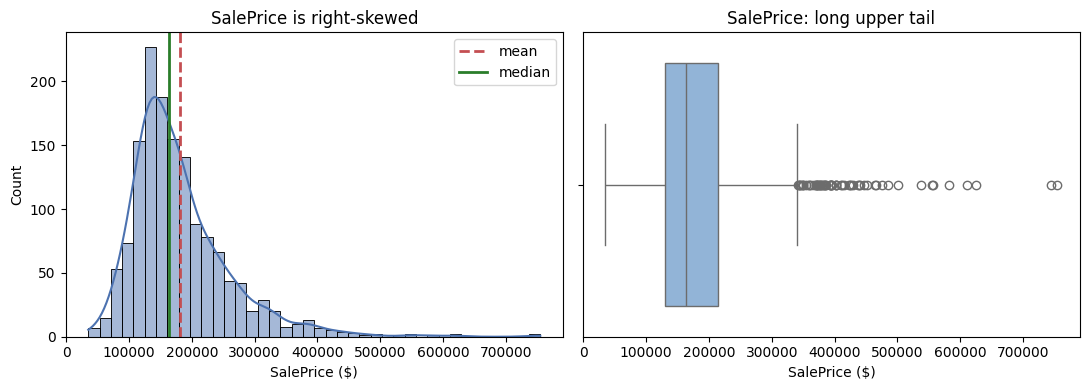

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["SalePrice"], bins=40, kde=True, color="#4c72b0", ax=axes[0])
axes[0].axvline(df["SalePrice"].mean(), color="#c44e52", ls="--", lw=2, label="mean")
axes[0].axvline(df["SalePrice"].median(), color="#2a7d2a", ls="-", lw=2, label="median")
axes[0].set_title("SalePrice is right-skewed"); axes[0].set_xlabel("SalePrice ($)"); axes[0].legend()
sns.boxplot(x=df["SalePrice"], color="#86b4e3", ax=axes[1])
axes[1].set_title("SalePrice: long upper tail"); axes[1].set_xlabel("SalePrice ($)")
fig.tight_layout(); plt.show()

<details><summary>Expected Output</summary>

*(A right-skewed histogram: most homes sell between $130k and $214k, the mean line sits to the right of
the median, and a long tail reaches past $500k. The box plot shows the same skew -- median left of
center, a long right whisker, and many flagged points (1.5xIQR) beyond it.)*
</details>

### 3b. OverallQual, the ordinal predictor (worked)

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64


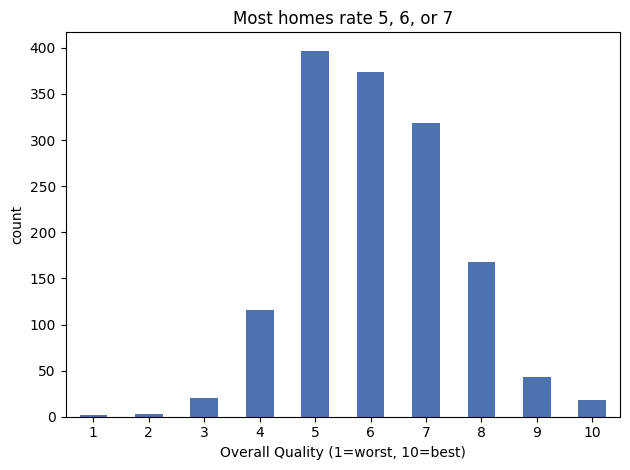

In [10]:
counts = df["OverallQual"].value_counts().sort_index()
print(counts)
counts.plot(kind="bar", color="#4c72b0", title="Most homes rate 5, 6, or 7")
plt.xlabel("Overall Quality (1=worst, 10=best)"); plt.ylabel("count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

<details><summary>Expected Output</summary>

~~~text
OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64
~~~
*(A bar chart centered on 5-6; very few homes earn 9 (43) or 10 (18) -- those drive the price extremes
from Step 3a.)*
</details>

### 3c. GrLivArea -- completion

`GrLivArea` is above-ground living area. Print its summary, then **uncomment and complete** a histogram
(choose a bin count between 20 and 50, add the KDE):

In [11]:
print(df["GrLivArea"].describe())
print(f"skew = {df['GrLivArea'].skew():.2f}")

# Uncomment and fill the two ____ blanks, then run:
# sns.histplot(df["GrLivArea"], bins=____, kde=____, color="#4c72b0")   # 30 bins; kde wants True/False
# plt.title("GrLivArea distribution"); plt.xlabel("Above-ground living area (sq ft)")
# plt.tight_layout(); plt.show()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64
skew = 1.37


<details><summary>Expected Output</summary>

~~~text
count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64
skew = 1.37
~~~
*(Right-skewed, skew 1.37: mean 1,515 > median 1,464 sq ft; most homes 1,000-2,000 sq ft with a long
tail to ~5,600.)*
</details>

## Step 4: Bivariate -- Read Relationships VISUALLY

> **No correlation coefficient here.** The single number that measures how two variables move together --
> **correlation (Pearson's r)** -- is **L19**. In this lesson we read relationships the L09 way: with the
> **eye** (scatter) and with **group summaries** (median per group).

### 4a. Living area vs price, colored by quality (worked)

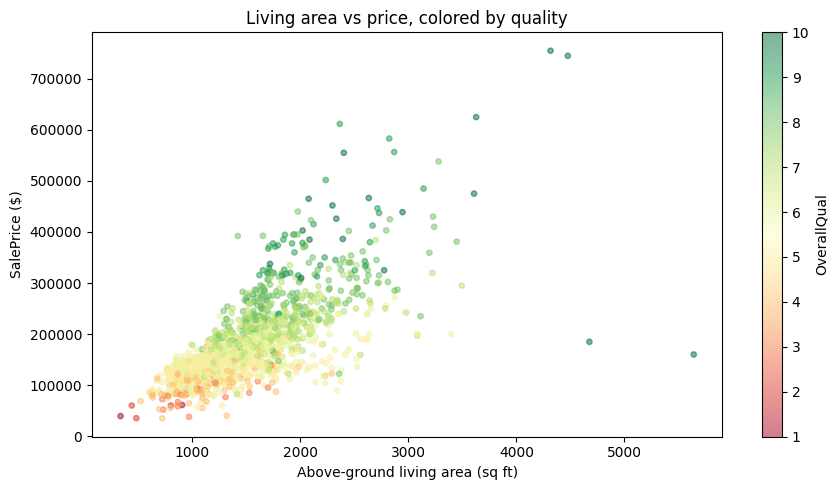

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(df["GrLivArea"], df["SalePrice"], c=df["OverallQual"], cmap="RdYlGn", alpha=0.5, s=15)
fig.colorbar(sc, ax=ax, label="OverallQual")
ax.set_xlabel("Above-ground living area (sq ft)"); ax.set_ylabel("SalePrice ($)")
ax.set_title("Living area vs price, colored by quality"); plt.tight_layout(); plt.show()

<details><summary>Expected Output</summary>

*(A scatter with a clear **positive**, roughly **linear** trend -- bigger homes cost more -- but the
cloud **fans out**: at 2,000 sq ft, prices run from ~$100k to ~$350k. The color explains the spread:
green (high quality) dots ride the top of the band, red (low quality) the bottom. Size and quality
together tell the story. Read by eye -- no number computed.)*
</details>

### 4b. Price by quality -- the group-summary story (worked)

The scatter hinted that quality matters. Make it explicit with a **median per group** (no coefficient):

OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0
Name: SalePrice, dtype: float64


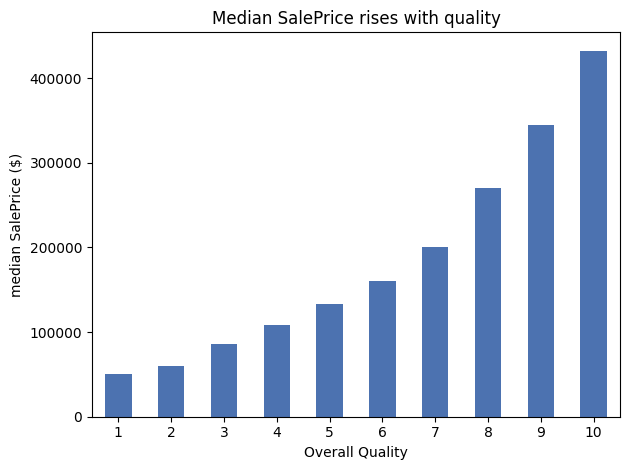

In [13]:
med_by_qual = df.groupby("OverallQual")["SalePrice"].median()
print(med_by_qual)
med_by_qual.plot(kind="bar", color="#4c72b0", title="Median SalePrice rises with quality")
plt.xlabel("Overall Quality"); plt.ylabel("median SalePrice ($)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

<details><summary>Expected Output</summary>

~~~text
OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0
Name: SalePrice, dtype: float64
~~~
*(Median price climbs monotonically with quality: a quality-9 home's median ($345,000) is about **2.6x**
a quality-5 home's ($133,000). "Quality drives price" -- shown with group medians, not a correlation.)*
</details>

### 4c. Price by house style -- grouped box plot (worked)

A **grouped box plot** is just L08's box plot drawn once **per category**, side by side -- so you compare
a numeric variable's distribution across groups at a glance:

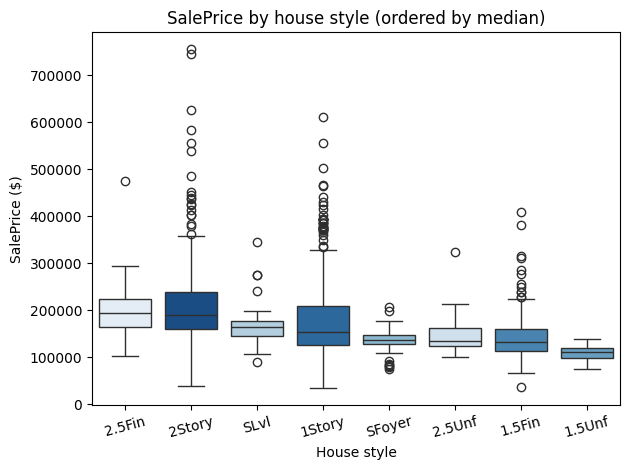

In [14]:
order = df.groupby("HouseStyle")["SalePrice"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="HouseStyle", y="SalePrice", hue="HouseStyle",
            order=order, palette="Blues_r", legend=False)
plt.title("SalePrice by house style (ordered by median)")
plt.xlabel("House style"); plt.ylabel("SalePrice ($)")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

<details><summary>Expected Output</summary>

*(Eight boxes ordered by median: 2.5Fin (~$194k) and 2Story (~$190k) highest -- but 2.5Fin rests on only
8 homes, so trust the widest, best-sampled boxes most -- and 1.5Unf (~$111k) lowest. 1Story dominates by
count (726) and shows a wide interquartile range: lots of price variability even within one style.)*
</details>

## Step 5: Synthesis -- Your Findings

EDA ends in **sentences**, not just plots. **Uncomment and fill** three findings (one sentence each):

In [15]:
# Uncomment and fill the three strings, then run:
# finding_1 = "____"   # the strongest driver of SalePrice, and why (hint: Steps 4a-4b)
# finding_2 = "____"   # one surprising or counter-intuitive result
# finding_3 = "____"   # one limitation of this analysis or dataset
# print("=== EDA Findings: Ames Housing ===")
# print(f"1. Strongest driver: {finding_1}")
# print(f"2. Surprising:       {finding_2}")
# print(f"3. A limitation:     {finding_3}")

<details><summary>Sample Answers</summary>

~~~text
=== EDA Findings: Ames Housing ===
1. Strongest driver: OverallQual -- median price climbs steadily with it, from $133k at 5 to $345k at 9.
2. Surprising:       The price cloud fans out widely at any given size; size alone does not fix price.
3. A limitation:     One Midwestern city, 2006-2010 (a crash window); patterns may not transfer to PR.
~~~
</details>

## Your Turn

### Exercise 1 -- Written: imputation assumptions

`LotFrontage` was filled with the median. Under what missingness assumption is that reasonable? If the
blanks instead meant "this lot genuinely has no street frontage," why would median-filling mislead, and
what would you do instead? *(Hint: a value can be missing at random, or missing for a reason. Filling 69
ft for a lot with truly zero frontage is not neutral.)*

### Exercise 2 -- Code: LotArea vs SalePrice (read by eye)

Plot a scatter of `LotArea` (x) vs `SalePrice` (y). Read it the L09 way -- direction, form, strength,
unusual points -- in two sentences. (No correlation number; that is L19.)

In [16]:
# TODO: your code here (one scatter, then two sentences as a comment)

<details><summary>Expected Output</summary>

*(A scatter with LotArea on x and SalePrice on y. The cloud is **wider and noisier** than the GrLivArea
scatter, with several very large lots that did NOT fetch high prices -- a weak, positive, loosely linear
trend. A bigger lot does not reliably mean a higher price.)*
</details>

### Exercise 3 -- Open-ended: explore a column we skipped

Pick one numeric column we did not feature (`GarageArea`, `FullBath`, `YearBuilt`, ...). Make one plot
(histogram, or a scatter against `SalePrice`), and write two sentences on what you see -- shape, or the
visual relationship to price.

In [17]:
# TODO: your code here

## Summary

| Step | Key commands | What you did |
|------|--------------|--------------|
| First look | `dtypes`, `isnull().sum()`, `describe()` | structure, quality, headline numbers |
| Clean | `fillna(median())`, `fillna(0)` | targeted impute beats `dropna()` (kept 265 rows) |
| Univariate | `histplot`, `boxplot`, `value_counts` + bar | shape, spread, skew per variable |
| Bivariate (visual) | `scatter`, `groupby().median()` + bar, grouped `boxplot` | relationships by eye and by group -- no `r` |
| Synthesis | written findings | EDA ends in sentences, with stated limits |

You ran the full Unit III loop on an unfamiliar dataset. **Unit IV** turns these patterns into *features*
and *models* -- and **L19** finally puts a number (correlation) on the relationships you read by eye here.